In [31]:

import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from pathlib import Path
import matplotlib.patches as mpatches

from src.data.data import load_trade_data
from src.analysis.models import PCAModel

In [32]:
X, factors, chapters = load_trade_data()

In [33]:
X.shape
factors

,Year,Partner
0,2003,CHN
1,2003,ROW
2,2004,CHN
3,2004,ROW
4,2005,CHN
5,2005,ROW
6,2006,CHN
7,2006,ROW
8,2007,CHN
9,2007,ROW


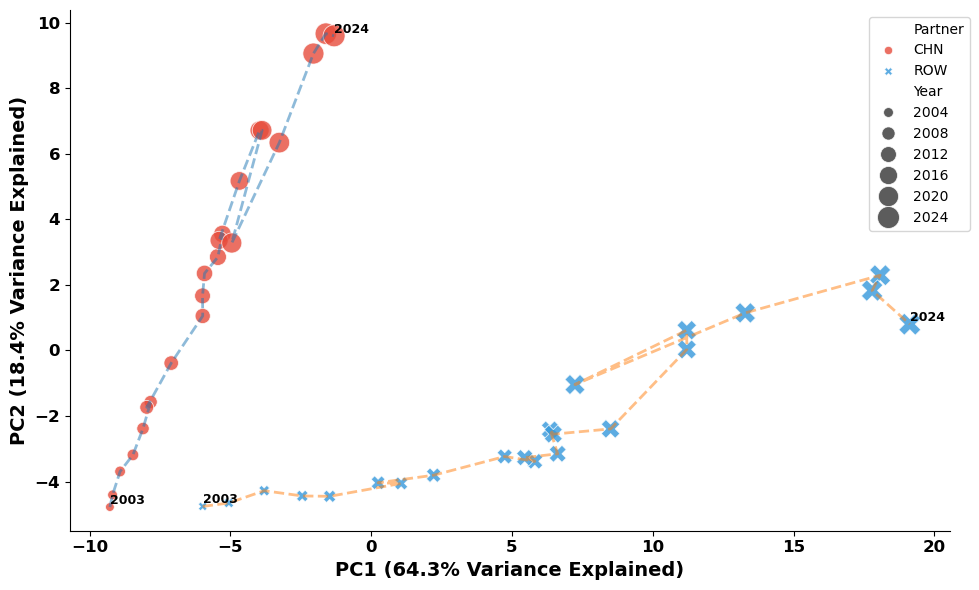

In [34]:
plt.figure(figsize=(10, 6))

pca_global = PCAModel(n_components=0.99)
pca_global = pca_global.fit(X)

plot_df = factors.copy()
plot_df['PC1'] = pca_global.scores[:, 0]
plot_df['PC2'] = pca_global.scores[:, 1]

sns.scatterplot(
    data=plot_df,
    x='PC1', 
    y='PC2', 
    hue='Partner', 
    style='Partner',
    size='Year', 
    sizes=(40, 250), 
    alpha=0.8,
    palette=['#e74c3c', '#3498db']
)

for partner in plot_df['Partner'].unique():
    partner_data = plot_df[plot_df['Partner'] == partner].sort_values('Year')
    
    plt.plot(
        partner_data['PC1'], 
        partner_data['PC2'], 
        alpha=0.5,         
        linewidth=2, 
        linestyle='--',      
        zorder=1
    )

sns.despine()

var_pc1 = pca_global.variance_ratio[0] * 100
var_pc2 = pca_global.variance_ratio[1] * 100

plt.xlabel(f'PC1 ({var_pc1:.1f}% Variance Explained)', fontsize=14, fontweight='bold')
plt.ylabel(f'PC2 ({var_pc2:.1f}% Variance Explained)', fontsize=14, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.legend(bbox_to_anchor=(0.9, 1), loc='upper left')

for partner in plot_df['Partner'].unique():
    partner_data = plot_df[plot_df['Partner'] == partner].sort_values('Year')
    start = partner_data.iloc[0]
    end = partner_data.iloc[-1]
    plt.text(start['PC1'], start['PC2'] + 0.1, str(start['Year']), fontsize=9, fontweight='bold')
    plt.text(end['PC1'], end['PC2'] + 0.1, str(end['Year']), fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/pca_nature.png', dpi=600)
plt.show()

In [35]:
plot_df

,Year,Partner,PC1,PC2
0,2003,CHN,-9.281625,-4.776433
1,2003,ROW,-5.985112,-4.757165
2,2004,CHN,-9.187024,-4.405625
3,2004,ROW,-5.055859,-4.651939
4,2005,CHN,-8.919186,-3.691088
5,2005,ROW,-3.802405,-4.278220
6,2006,CHN,-8.463859,-3.186021
7,2006,ROW,-2.448874,-4.438175
8,2007,CHN,-8.105638,-2.381905
9,2007,ROW,-1.477341,-4.449052


The PCA plot shows the indias nature of imports from the China and the Rest of the world. In the 2003 the chinease and the rest of the imports were close togeather and by 2024 the gap has increased aggressively. This widening gap proves that India is not simply trading higher volumes with China; it is trading a fundamentally different basket of goods. The strategic implication is clear: India cannot simply execute a "plug-and-play" substitution by shifting its existing Chinese orders to the rest of the world, because the ROW matrix is structurally misaligned with the specific industrial footprint China currently occupies in India's economy.

To understand exactly what is dragging the China trajectory so far away from the global baseline, we see the positive loading from the PC1 which are 90, 38, 28, 39,76. These are not simple consumer electronics or cheap textiles but deep-tier industrial and advanced materials.

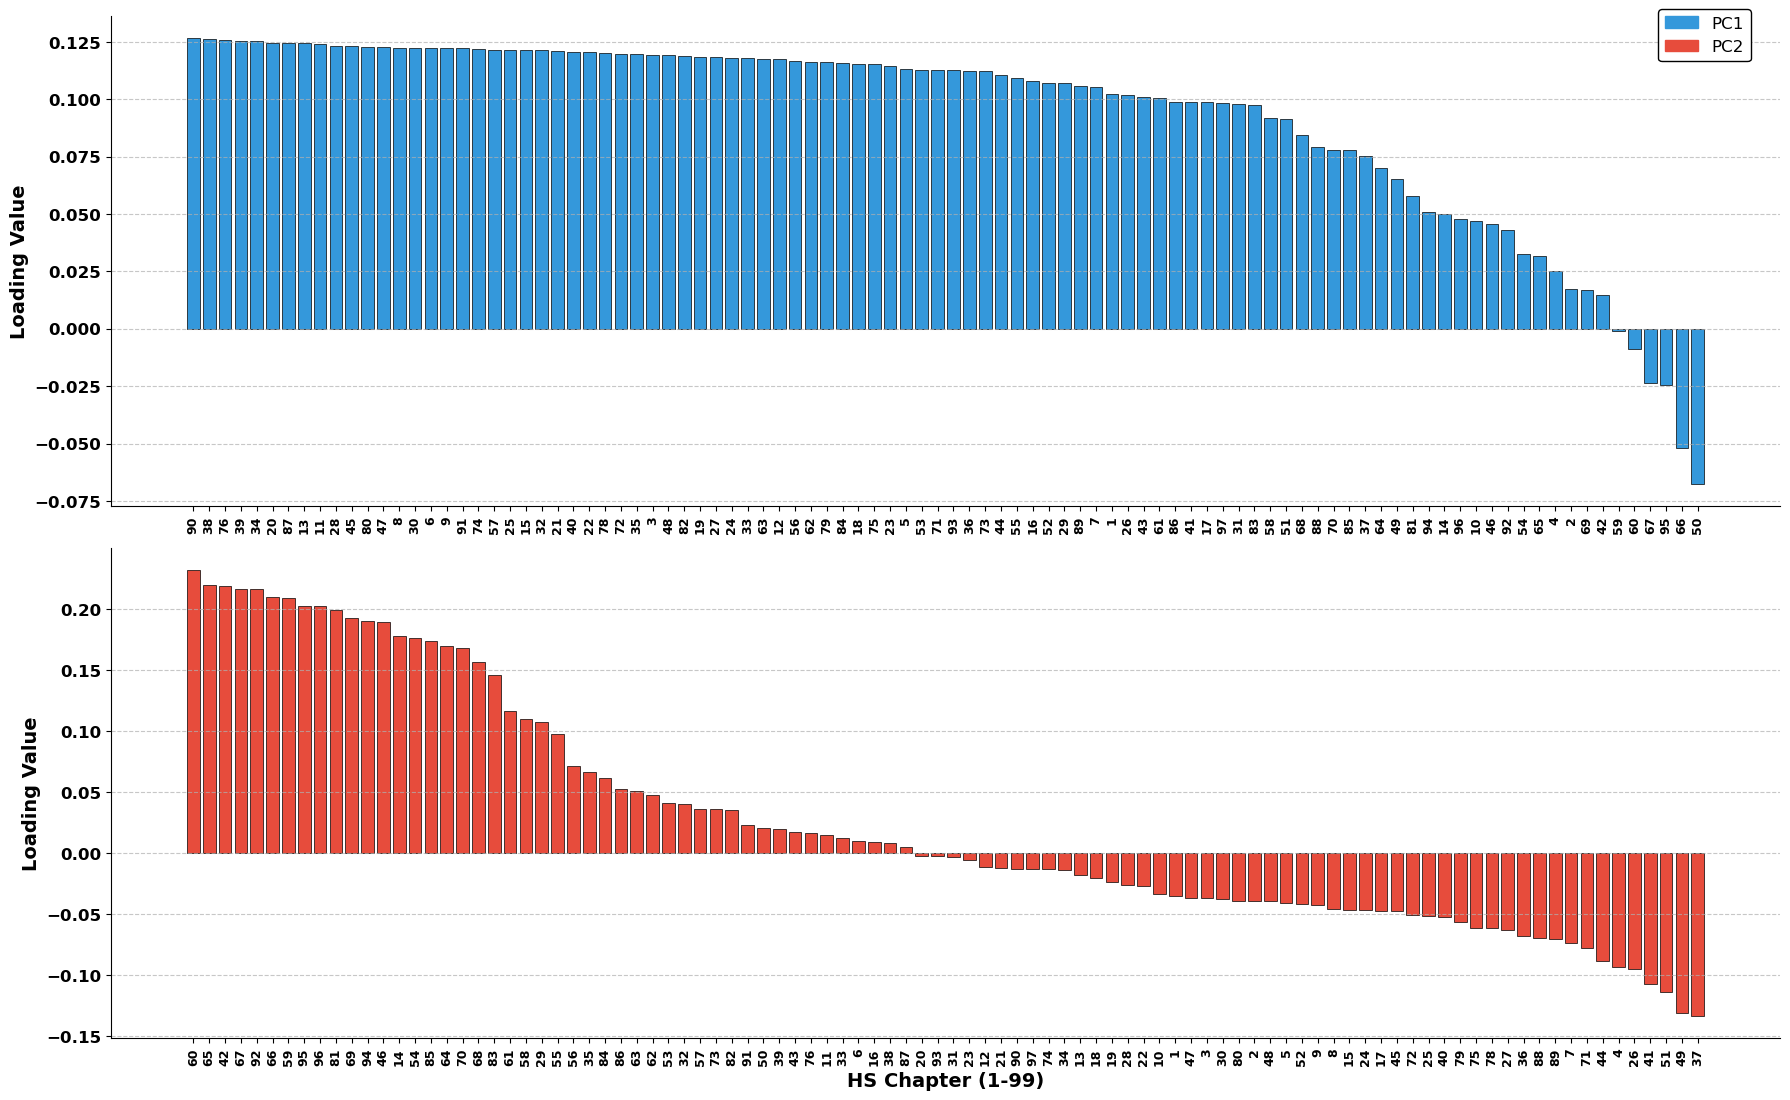

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

os.makedirs('figures', exist_ok=True)

# 1. Prepare Data
loadings_pc1 = np.array(pca_global.loadings[0])
loadings_pc2 = np.array(pca_global.loadings[1])
chapter_labels = np.array([str(c) for c in chapters])

# 2. Create independent sorting indices (Descending)
idx_pc1 = np.argsort(loadings_pc1)[::-1]
idx_pc2 = np.argsort(loadings_pc2)[::-1]

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# --- Subplot 1: PC1 (Sorted by PC1) ---
axes[0].bar(chapter_labels[idx_pc1], loadings_pc1[idx_pc1], 
            color='#3498db', edgecolor='black', linewidth=0.5)

var_pc1 = pca_global.variance_ratio[0] * 100
axes[0].set_ylabel('Loading Value', fontsize=14, fontweight='bold')

# --- Subplot 2: PC2 (Sorted by PC2) ---
axes[1].bar(chapter_labels[idx_pc2], loadings_pc2[idx_pc2], 
            color='#e74c3c', edgecolor='black', linewidth=0.5)

var_pc2 = pca_global.variance_ratio[1] * 100
axes[1].set_xlabel('HS Chapter (1-99)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Loading Value', fontsize=14, fontweight='bold')

# --- Shared Formatting ---
for ax in axes:
    ax.tick_params(axis='x', rotation=90, labelsize=9)
    ax.tick_params(axis='y', labelsize=12)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Legend
pos_patch = mpatches.Patch(color='#3498db', label='PC1')
neg_patch = mpatches.Patch(color='#e74c3c', label='PC2')
fig.legend(handles=[pos_patch, neg_patch], loc='upper right', 
           bbox_to_anchor=(0.98, 0.95), fontsize=12, framealpha=1, edgecolor='black')

sns.despine()            
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for legend/title

plt.savefig('figures/pca_loadings.png', dpi=600)
plt.show()

In [36]:
pca_global.variance_ratio

array([0.6430311 , 0.18362998, 0.0510075 , 0.02095676, 0.01667078,
       0.01646887, 0.01229205, 0.00781917, 0.00664431, 0.0059686 ,
       0.00492865, 0.00461201, 0.00409811, 0.00343074, 0.00308542,
       0.00229286, 0.00179913, 0.00157175])

In [40]:
pca_global.loadings[1]

array([-0.03504885, -0.03931263, -0.03675535, -0.09362775, -0.0409481 ,
        0.00993347, -0.07395011, -0.04548364, -0.0428857 , -0.03377994,
        0.01483393, -0.01122498, -0.01807854,  0.17784296, -0.04643891,
        0.00878437, -0.04785086, -0.02029198, -0.02381961, -0.00208504,
       -0.01223438, -0.02721645, -0.00555469, -0.04686278, -0.05196433,
       -0.09513333, -0.06298266, -0.02579592,  0.10726304, -0.03750044,
       -0.00331453,  0.03993717,  0.01261891, -0.01423442,  0.06658228,
       -0.06832811, -0.1335256 ,  0.00808034,  0.01941167, -0.05247372,
       -0.10718318,  0.21877611,  0.01730362, -0.08816512, -0.0478802 ,
        0.18947897, -0.03655311, -0.03931282, -0.13085791,  0.02028923,
       -0.11382704, -0.04167769,  0.04124747,  0.176514  ,  0.09754311,
        0.07170992,  0.03604599,  0.11010651,  0.2088852 ,  0.23165256,
        0.11651367,  0.04779629,  0.05122245,  0.1699017 ,  0.22003843,
        0.20972941,  0.21650488,  0.15663393,  0.19263545,  0.16

Based on the Principal Component Analysis (PCA) of the trade data, here is the detailed breakdown of the top 5 loadings for both $PC_1$ and $PC_2$. These loadings identify the specific "anchors" of India's trade profile.PC1: The "Industrial Backbone" (64.3% Variance)$PC_1$ represents the general expansion and industrialization of India’s trade. High loadings here indicate products that are essential for the overall scale of India's manufacturing economy.HS ChapterProduct DescriptionLoading ValueEconomic Implication90Optical, Medical & Precision Instruments$0.1266$Technological Dependency: India is increasingly importing the "brains" of its industry (sensors, medical gear, measuring tools).38Miscellaneous Chemical Products$0.1261$Process Dependency: Crucial catalysts and chemical agents needed to keep factories (electronics, textiles, pharma) running.76Aluminum and Articles thereof$0.1259$Infrastructure Foundation: Essential for the power sector, automotive lightweighting, and the growing EV market.39Plastics and Articles thereof$0.1255$Raw Material Lock-in: The fundamental material for packaging and consumer goods; India's domestic assembly is built on these imports.34Soap, Lubricants, and Waxes$0.1254$Operational Fuel: Represents industrial-grade lubricants and processing agents required for heavy machinery and manufacturing operations.Implication for $PC_1$: These chapters move in lockstep with India's GDP and industrial growth. Because China and the Rest of the World both score positively on this axis, it shows a global dependency. However, China’s massive volume makes it the "dominant baseline" for these critical industrial ingredients.PC2: The "China Specialization" (18.4% Variance)$PC_2$ represents the structural divergence. In your analysis, China is the only partner surging "up" on this axis, meaning these chapters define the unique gap between China and other trading partners.HS ChapterProduct DescriptionLoading ValueEconomic Implication60Knitted or Crocheted Fabrics$0.2317$Intermediate Supply Chain: India’s massive garment export industry relies on these specific fabric inputs that other partners don't provide at scale.65Headgear and parts thereof$0.2200$Niche Manufacturing: Reflects a high level of specialization in apparel accessories where China maintains a near-monopoly.42Leather Articles / Travel Goods$0.2188$Consumer Retail Dominance: High-volume retail sectors like luggage and leather goods are heavily tilted toward Chinese supply.67Prepared Feathers, Flowers, Hair$0.2165$Specialized Materials: Illustrates the "long tail" of specialized consumer materials that distinguish China's trade basket.92Musical Instruments$0.2162$Manufactured Precision: Shows dominance in complex, assembly-heavy consumer goods that require specific supply chain clusters.Implication for $PC_2$: The high loadings on $PC_2$ explain why China’s trade trajectory looks "alien" compared to the rest of the world. While the world provides commodities and standard industrial goods ($PC_1$), China provides a hyper-specialized variety of intermediate inputs ($PC_2$).Strategic Synthesis: The Dual-Axis ChallengeThe "Nature of Trade" revealed by these tables shows that India is caught in a two-dimensional dependency:The $PC_1$ Challenge: India needs to build massive domestic capacity for chemicals, plastics, and precision tools to match the volume currently supplied by the global market (and China).The $PC_2$ Challenge: India needs to foster niche manufacturing ecosystems (like knitted fabrics and specialized consumer components) because no other country currently offers the variety captured by China’s $PC_2$ signature.Conclusion: To truly "de-risk," India cannot just find "another China." It must find a way to replicate the Industrial Backbone ($PC_1$) and the Specialized Inputs ($PC_2$) simultaneously, a task that requires both heavy industrial investment and niche manufacturing clusters.

Shift in dominant oMEDA markers over time:
    Year Top_Chapter     Score
0   2003          50  0.560499
1   2004          50  1.047556
2   2005          50  2.128064
3   2006          50  1.659730
4   2007          50  2.007950
5   2008          50  1.892120
6   2009          50  1.991097
7   2010          50  1.774092
8   2011          69  1.529797
9   2012          69  1.442281
10  2013          95  1.483050
11  2014          69  1.695500
12  2015          69  1.970843
13  2016          95  1.689383
14  2017          94  2.009397
15  2018          42  2.539007
16  2019          42  2.201105
17  2020          14  2.270370
18  2021          54  2.275913
19  2022          81  3.078250
20  2023          54  3.748927
21  2024          70  2.955291


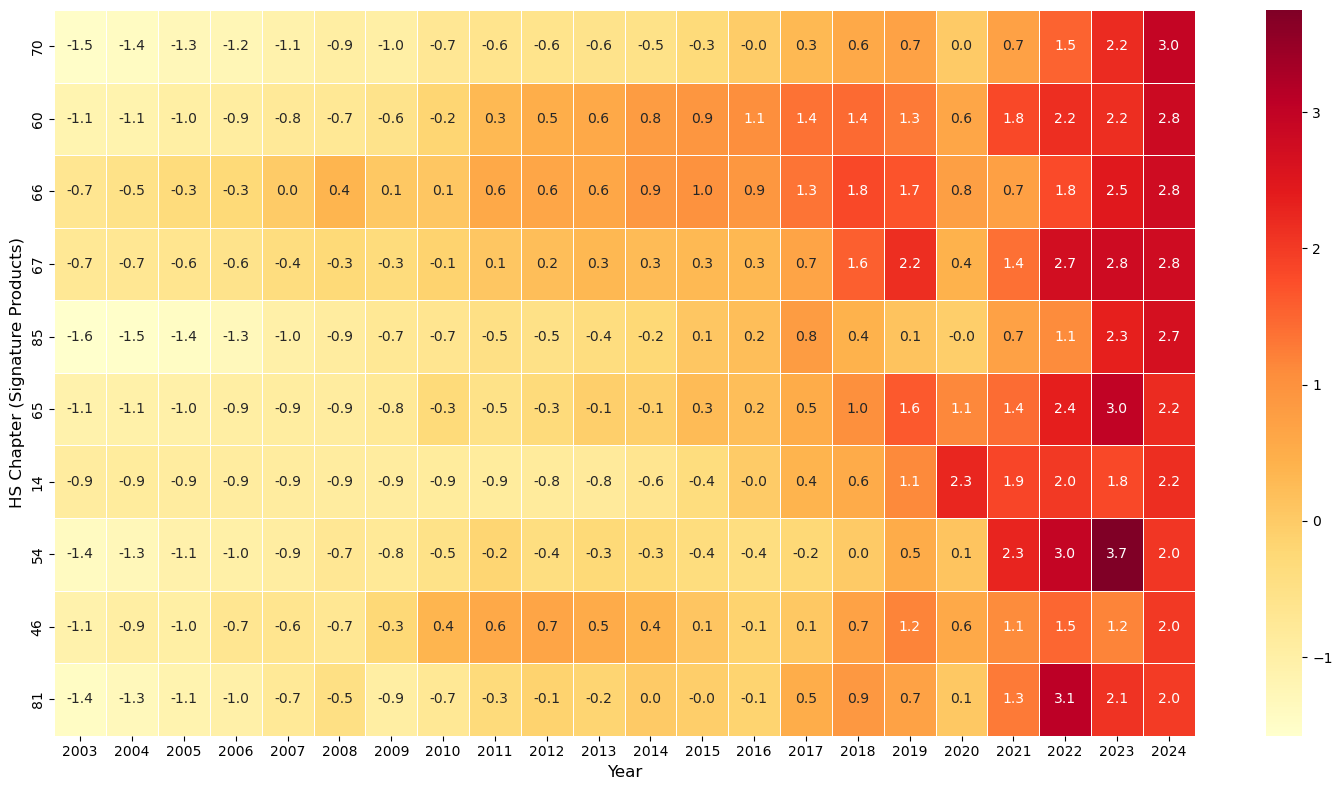

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the data
df = pd.read_csv('data/trade_pivot.csv')
chapter_cols = [col for col in df.columns if col not in ['Year', 'Partner']]
X = df[chapter_cols]

# 1. Standardize the entire dataset (Global scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=chapter_cols)

# Reattach metadata
analysis_df = pd.concat([df[['Year', 'Partner']], X_scaled_df], axis=1)

# 2. Iterate through every year to calculate China's oMEDA markers
years = sorted(df['Year'].unique())
omeda_time_series = []

for year in years:
    china_year_data = analysis_df[(analysis_df['Year'] == year) & (analysis_df['Partner'] == 'CHN')]
    if not china_year_data.empty:
        markers = china_year_data.iloc[0, 2:]
        markers_dict = markers.to_dict()
        markers_dict['Year'] = year
        omeda_time_series.append(markers_dict)

# 3. Create a DataFrame for oMEDA scores over time
omeda_pivot = pd.DataFrame(omeda_time_series).set_index('Year')

# 4. Identify the top markers (highest average scores over time or highest final scores)
# Let's take the top 10 markers in 2024 and track them historically
top_2024_chapters = omeda_pivot.loc[2024].sort_values(ascending=False).head(10).index.tolist()

# 5. Visualization: Heatmap of top markers over time
plt.figure(figsize=(15, 8))
sns.heatmap(omeda_pivot[top_2024_chapters].T, cmap='YlOrRd', annot=True, fmt=".1f", linewidths=.5)
plt.xlabel('Year', fontsize=12)
plt.ylabel('HS Chapter (Signature Products)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/omeda_evolution_heatmap.png', dpi=600)

# 6. Analyze the shift in leading markers (Top marker per year)
top_per_year = []
for year in years:
    top_chapter = omeda_pivot.loc[year].idxmax()
    top_score = omeda_pivot.loc[year].max()
    top_per_year.append({'Year': year, 'Top_Chapter': top_chapter, 'Score': top_score})

top_per_year_df = pd.DataFrame(top_per_year)
print("Shift in dominant oMEDA markers over time:")
print(top_per_year_df)

omeda_pivot.to_csv('omeda_all_years.csv')

In [43]:
china_year_data

,Year,Partner,1,2,3,4,5,6,7,8,...,88,89,90,91,92,93,94,95,96,97
42,2024,CHN,-0.620232,-0.228456,-0.753767,-0.490436,-0.874036,0.226274,-0.783023,-0.783234,...,-0.655911,-0.908869,-0.188289,0.744784,1.664822,-0.546397,1.140516,1.232282,1.974632,-0.516857
